In [1]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from pathlib import Path

Path("models").mkdir(exist_ok=True)
Path("outputs").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)

df = pd.read_parquet("data/news_clean_ai.parquet")

docs = df["article_text"].tolist()

In [2]:
df_sample = df.sample(n=min(30000, len(df)), random_state=42)
docs = df_sample["article_text"].tolist()

In [3]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=100,
    verbose=True
)

topics, probs = topic_model.fit_transform(docs)

df_sample["topic"] = topics
df_sample["topic_prob"] = probs

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-05-19 17:02:18,892 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/938 [00:00<?, ?it/s]

2026-05-19 17:34:06,092 - BERTopic - Embedding - Completed ✓
2026-05-19 17:34:06,093 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-19 17:34:40,539 - BERTopic - Dimensionality - Completed ✓
2026-05-19 17:34:40,542 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-19 17:34:49,624 - BERTopic - Cluster - Completed ✓
2026-05-19 17:34:49,644 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-19 17:39:55,017 - BERTopic - Representation - Completed ✓


In [4]:
topic_info = topic_model.get_topic_info()
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,13683,-1_the_to_and_of,"[the, to, and, of, in, ai, for, on, is, with]",[Europe's AI Act talks head for crunch point. ...
1,0,4442,0_and_the_of_to,"[and, the, of, to, ai, in, for, with, gray, pr...",[7 Challenges of AI Integration in Healthcare ...
2,1,1467,1_the_ago_to_in,"[the, ago, to, in, of, and, that, for, on, hours]",[Why actors are fighting for AI protections | ...
3,2,1334,2_india_share_in_the,"[india, share, in, the, to, and, of, ai, on, for]",[generative AI: ETtech Opinion: Generative AI ...
4,3,940,3_chatgpt_to_the_openai,"[chatgpt, to, the, openai, and, of, in, it, fo...",[Google Vs. ChatGPT: Here's What Happened When...
5,4,737,4_all_ment_products_overviewview,"[all, ment, products, overviewview, services, ...",[Fujitsu to provide the world's first enterpri...
6,5,537,5_apple_to_best_the,"[apple, to, best, the, iphone, and, ai, mobile...",[Insider Q&A: CIA's chief technologist's cauti...
7,6,516,6_us_newswires_by_presswire,"[us, newswires, by, presswire, ein, and, ai, r...",[AI in Telecommunication Market News: Advancem...
8,7,511,7_nvidia_the_ai_and,"[nvidia, the, ai, and, to, of, for, in, with, ...",[Nvidia’s Grip On AI Chips Produces Blockbuste...
9,8,490,8_npr_the_radio_schedule,"[npr, the, radio, schedule, news, of, music, p...",[10 reasons why AI may be overrated | WYSO. 10...


In [5]:
topic_info.to_csv("outputs/topic_info.csv", index=False)
df_sample.to_parquet("data/news_with_topics.parquet", index=False)
topic_model.save("models/bertopic_ai_news")

2026-05-19 17:40:30,584 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [6]:
topic_keywords = []

for topic_id in topic_info["Topic"].unique():
    if topic_id == -1:
        continue
    
    words = topic_model.get_topic(topic_id)
    if words:
        keywords = ", ".join([w for w, score in words[:10]])
        topic_keywords.append({
            "topic": topic_id,
            "keywords": keywords
        })

topic_keywords_df = pd.DataFrame(topic_keywords)
topic_keywords_df.to_csv("outputs/topic_keywords.csv", index=False)
topic_keywords_df.head(20)

,topic,keywords
0,0,"and, the, of, to, ai, in, for, with, gray, prn..."
1,1,"the, ago, to, in, of, and, that, for, on, hours"
2,2,"india, share, in, the, to, and, of, ai, on, for"
3,3,"chatgpt, to, the, openai, and, of, in, it, for..."
4,4,"all, ment, products, overviewview, services, c..."
5,5,"apple, to, best, the, iphone, and, ai, mobile,..."
6,6,"us, newswires, by, presswire, ein, and, ai, re..."
7,7,"nvidia, the, ai, and, to, of, for, in, with, amd"
8,8,"npr, the, radio, schedule, news, of, music, pu..."
9,9,"ai, and, to, the, data, of, for, business, in, is"


In [7]:
topic_labels = {
    0: "Generative AI and LLM Adoption",
    1: "Healthcare AI and Diagnostics",
    2: "AI in Finance and Risk Analytics",
    3: "Robotics and Manufacturing Automation",
    4: "Legal and Professional Services Automation",
    5: "AI Chips and Cloud Infrastructure",
}

In [8]:
df_sample["topic_label"] = df_sample["topic"].map(topic_labels).fillna("Other / Mixed Topic")

df_sample.to_parquet("data/news_with_topics_labeled.parquet", index=False)

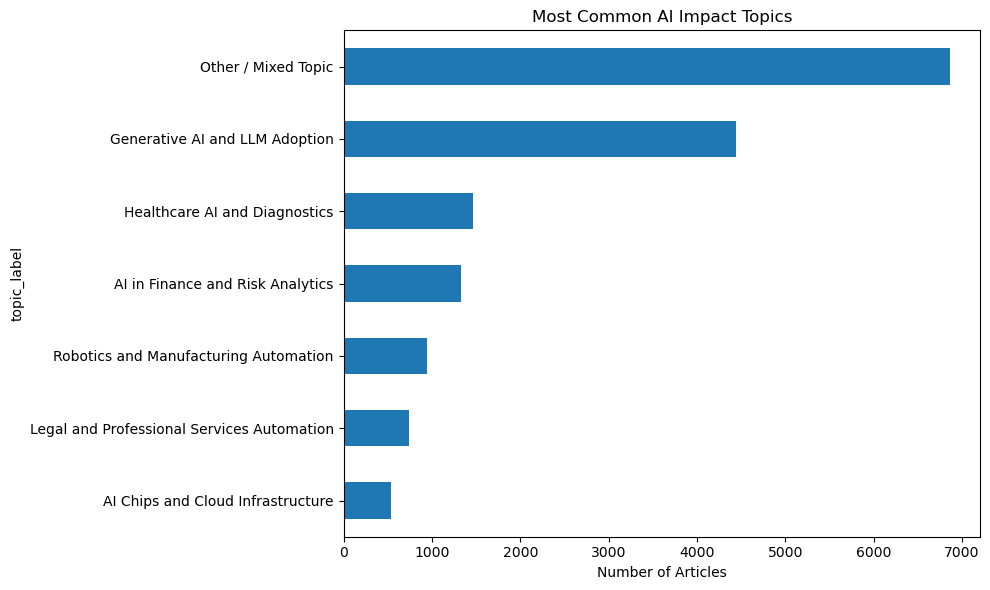

In [9]:
import matplotlib.pyplot as plt

top_topics = (
    df_sample[df_sample["topic"] != -1]
    ["topic_label"]
    .value_counts()
    .head(12)
)

plt.figure(figsize=(10,6))
top_topics.sort_values().plot(kind="barh")
plt.xlabel("Number of Articles")
plt.title("Most Common AI Impact Topics")
plt.tight_layout()
plt.savefig("figures/topic_distribution.png", dpi=300)
plt.show()